In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.inspection import DecisionBoundaryDisplay
from lightgbm import LGBMClassifier
from lightgbm import plot_importance
from sklearn.inspection import permutation_importance


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from src.config import DADOS_LIMPOS
from src.models import RANDOM_STATE

In [45]:
df = pd.read_parquet(DADOS_LIMPOS)
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.9 KB


In [47]:
X = df.drop(columns=["Species"])
y = df["Species"]

In [48]:
le = LabelEncoder()
y = le.fit_transform(y)
y[:5]

array([0, 0, 0, 0, 0])

In [49]:
le.classes_

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [50]:
le.inverse_transform([0, 1, 2])

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [52]:
np.bincount(y_train), np.bincount(y_test)

(array([40, 40, 40]), array([10, 10, 10]))

In [53]:
clf = LGBMClassifier(n_jobs=-1,verbose=-1, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [54]:
y_pred = clf.predict(X_test)

In [55]:
clf.score(X_test, y_test)

0.9

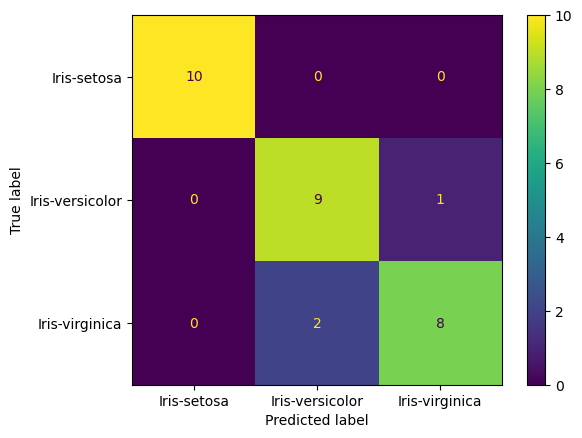

In [56]:
#Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot();

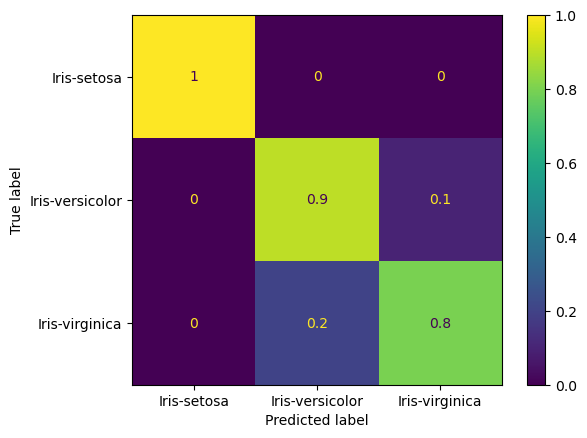

In [57]:
#Matriz de confusão
cm = confusion_matrix(y_test, y_pred, normalize="true")
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot();

In [58]:
#Report de classificação
print(classification_report(y_test, y_pred, target_names=le.classes_))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



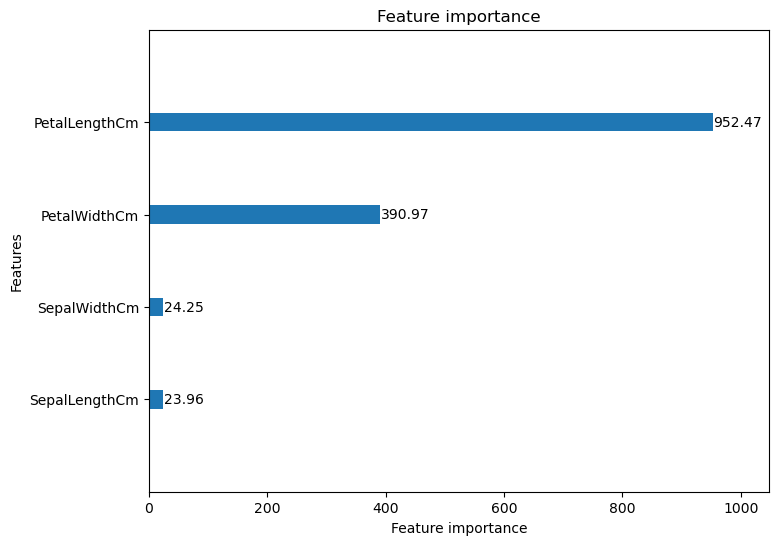

In [59]:
plot_importance(clf, importance_type="gain", grid=False, figsize=(8, 6),precision=2)
plt.show()

<Axes: ylabel='feature'>

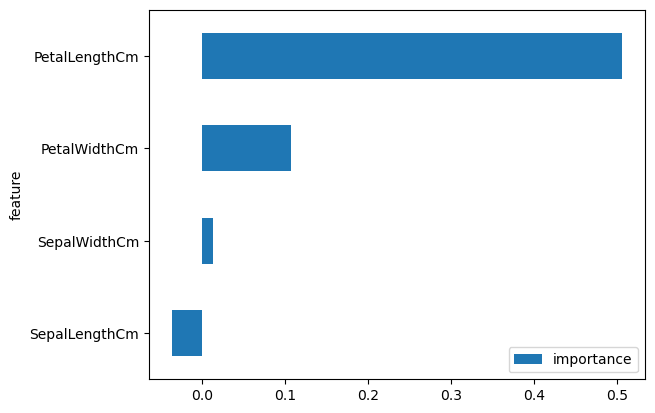

In [60]:
#Permutaion importance
result = permutation_importance(clf, X_test, y_test, n_repeats=10, random_state=RANDOM_STATE)
perm_importance = pd.DataFrame(
    {"feature": X.columns, "importance": result.importances_mean}
).sort_values("importance", ascending=True)

perm_importance.plot.barh(x="feature", y="importance")


Vizualizando os limites de decisão de um classificador

In [61]:
X_2d = X[["PetalLengthCm", "PetalWidthCm"]]
X_train, X_test, y_train, y_test = train_test_split(
    X_2d, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [62]:
clf = LGBMClassifier(n_jobs=-1,verbose=-1, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [63]:
clf.score(X_test, y_test)

0.9666666666666667

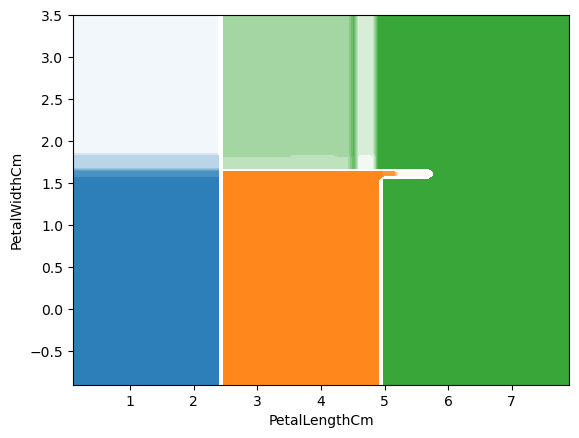

In [64]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X_train)

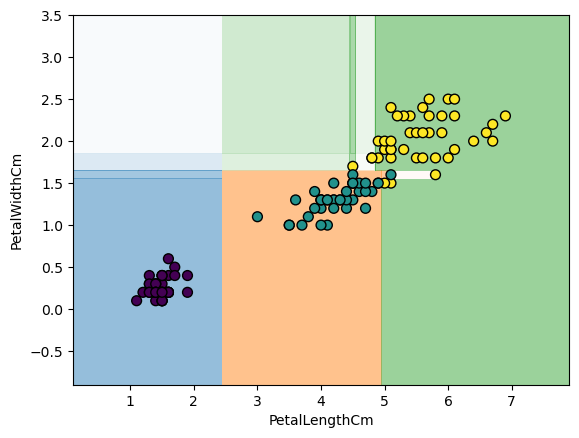

In [65]:
disp = DecisionBoundaryDisplay.from_estimator(
    clf, X_train,grid_resolution=1000, alpha = 0.5)

disp.ax_.scatter(X_train["PetalLengthCm"], X_train["PetalWidthCm"], c=y_train, edgecolor="k", s=50);

